## Path configuration

In [1]:
from pathlib import Path
import os

PROJECT_NAME = "MALDIAlign"

cwd = Path().resolve()

# Walk upwards until we find the project folder
target = None
for parent in [cwd] + list(cwd.parents):
    if parent.name == PROJECT_NAME:
        target = parent
        break

# If the project folder is found and we are not already there, then change cwd
if target is not None and target != cwd:
    os.chdir(target)

print("Working directory:", os.getcwd())

Working directory: /export/usuarios01/agnavarr/MALDIAlign


## Imports

In [2]:
import os
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils.load_config import load_config
from utils.load_data import load_pkl
from utils.eval import eval_model
from utils.viz import *

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

## Data preparation

### Data loading

In [3]:
cfg = load_config()
driams_pkl = cfg["data"]["DRIAMS_REDUCED_PKL"]

In [4]:
driams = load_pkl(driams_pkl)

In [5]:
data, label, meta = driams["data"], driams["label"], driams["meta"]

In [6]:
meta = pd.DataFrame.from_records(list(meta))

### Filter data and construct final dataset

In [7]:
maskA = np.where(meta["hospital"].values == "DRIAMS_A")[0]
dataA, labelA, metaA = data[maskA], label[maskA], meta.iloc[maskA]

maskD = np.where(meta["hospital"].values == "DRIAMS_D")[0]
dataD, labelD, metaD = data[maskD], label[maskD], meta.iloc[maskD]

In [8]:
# Downsample DRIAMS-A
from sklearn.model_selection import train_test_split

_, dataA_sub, _, labelA_sub, _, metaA_sub = train_test_split(
    dataA,
    labelA,
    metaA,
    test_size=len(dataD),
    random_state=42,
    stratify=labelA)

In [9]:
# Concatenate data and labels
data_final = np.vstack([dataA_sub, dataD])
label_final = np.concatenate([labelA_sub, labelD])
meta_final  = pd.concat([metaA_sub, metaD], ignore_index=True)

In [10]:
species, counts = np.unique(labelA_sub, return_counts=True)
for sp, n in zip(species, counts):
    print(f"{sp}: {n}")

Enterobacter_cloacae_complex: 676
Enterococcus_Faecium: 473
Escherichia_Coli: 1940
Klebsiella_Pneumoniae: 1073
Pseudomonas_Aeruginosa: 1290
Staphylococcus_Aureus: 1856


In [11]:
species, counts = np.unique(labelD, return_counts=True)
for sp, n in zip(species, counts):
    print(f"{sp}: {n}")

Enterobacter_cloacae_complex: 437
Enterococcus_Faecium: 171
Escherichia_Coli: 2013
Klebsiella_Pneumoniae: 2151
Pseudomonas_Aeruginosa: 362
Staphylococcus_Aureus: 2174


### Construct dataloaders

In [12]:
domain_map = {"DRIAMS_A": 0, "DRIAMS_D": 1}
domain_ids = meta_final["hospital"].map(domain_map).values

In [13]:
X_train, X_val, y_train, y_val, domain_train, domain_val = train_test_split(
    data_final, label_final, domain_ids,
    test_size=0.2, random_state=42, stratify=label_final
)

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [15]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val, dtype=torch.float32)

In [16]:
domain_train_tensor = torch.tensor(domain_train, dtype=torch.long)
domain_val_tensor   = torch.tensor(domain_val, dtype=torch.long)

In [17]:
train_dataset = TensorDataset(X_train_tensor, domain_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, domain_val_tensor)

In [18]:
targets = domain_train_tensor
class_counts = np.bincount(targets)
class_weights = 1. / class_counts
sample_weights = class_weights[targets]

sample_weights = torch.from_numpy(sample_weights).double()

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    sampler=sampler,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

## Architecture

In [ ]:
class CommonEncoder(nn.Module):
  def __init__(self, input_dim, latent_dim):
    super().__init__()

    self.net = nn.Sequential(
        nn.Linear(input_dim, 512),
        nn.ReLU(),
        nn.Linear(512, 256),
        nn.ReLU()
    )

    self.mu = nn.Linear(256, latent_dim)
    self.logvar = nn.Linear(256, latent_dim)

  def forward(self, x):
    hidden_rep = self.net(x)
    mu = self.mu(hidden_rep)
    logvar = self.logvar(hidden_rep)
    logvar = torch.clamp(logvar, -6, 6)
    return mu, logvar

In [ ]:
class Decoders(nn.Module):
  def __init__(self, latent_dim, output_dim, num_domains):
    super().__init__()

    self.net = nn.ModuleList([
      nn.Sequential(
        nn.Linear(latent_dim, 256),
        nn.ReLU(),
        nn.Linear(256, 512),
        nn.ReLU(),
        nn.Linear(512, output_dim)
    ) for _ in range(num_domains)
    ])

  def forward(self, z, domain_id):
    return self.net[domain_id](z)

In [ ]:
class MultiVAE(nn.Module):
  def __init__(self, input_dim, latent_dim, num_domains):
    super().__init__()
    self.encoder = CommonEncoder(input_dim, latent_dim)
    self.decoder = Decoders(latent_dim, input_dim, num_domains)

  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5*logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

  def forward(self, x, domain_id):
    mu, logvar = self.encoder(x)
    z = self.reparameterize(mu, logvar)

    x_recon = torch.zeros_like(x)

    for d in range(len(self.decoder.net)):
        mask = (domain_id == d)
        if mask.any():
            x_recon[mask] = self.decoder.net[d](z[mask])

    return x_recon, mu, logvar

In [ ]:
class MultiVAE_CORALM(MultiVAE):
  def __init__(self, input_dim, latent_dim, num_domains, epochs=100, lr=1e-4, annealing_epochs=50):
    super().__init__(input_dim, latent_dim, num_domains)

    self.epochs = epochs
    self.lr = lr
    self.annealing_epochs = annealing_epochs

    self.optimizer = optim.Adam(self.parameters(), lr=self.lr, weight_decay=1e-5)
    self.criterion = nn.MSELoss()

    self.loss_during_training = []
    self.reconstruc_during_training = []
    self.KL_during_training = []
    self.coral_loss_during_training = []

  def loss_function(self, x, x_recon, mu, logvar, beta):
    recon_loss = self.criterion(x_recon, x)
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

  def compute_coral(self, z_a, z_b):
    mean_diff = torch.mean((z_a.mean(0) - z_b.mean(0)) ** 2)
    z_a = z_a - z_a.mean(0)
    z_b = z_b - z_b.mean(0)

    cov_a = (z_a.T @ z_a) / (z_a.shape[0]-1)
    cov_b = (z_b.T @ z_b) / (z_b.shape[0]-1)

    coral_loss = torch.mean((cov_a - cov_b)**2)
    coral_loss = coral_loss / (4*(z_a.shape[1]**2))

    return coral_loss + mean_diff

  def trainloop(self, trainloader, validloader, device):
    self.to(device)

    for epoch in range(self.epochs):
      beta = min(1.0, (epoch + 1) / self.annealing_epochs)

      # TRAIN
      self.train()
      train_total_loss, train_recon_loss, train_kl_loss, train_coral_loss = 0, 0, 0, 0

      for x, domain_id in trainloader:
        x = x.to(device)
        domain_id = domain_id.to(device)
        self.optimizer.zero_grad()
        x_recon, mu, logvar = self.forward(x, domain_id)
        loss, recon, kl = self.loss_function(x, x_recon, mu, logvar, beta=beta)

        # CORAL
        mask_A = (domain_id == 0 )
        mask_D = (domain_id == 1)
        if mask_A.any() and mask_D.any():
            z = self.reparameterize(mu, logvar)
            coral_loss = self.compute_coral(z[mask_A], z[mask_D])
            lambda_coral = 1e-3
            loss = loss + lambda_coral * coral_loss
            train_coral_loss += coral_loss.item()

        loss.backward()
        self.optimizer.step()
        train_total_loss += loss.item()
        train_recon_loss += recon.item()
        train_kl_loss += kl.item()

      train_total_loss = train_total_loss / len(trainloader)
      train_recon_loss = train_recon_loss / len(trainloader)
      train_kl_loss = train_kl_loss / len(trainloader)
      train_coral_loss = train_coral_loss / len(trainloader)

      # VALIDATION
      self.eval()
      val_loss, val_recon, val_kl, val_coral = 0, 0, 0, 0

      with torch.no_grad():
        for x, domain_id in validloader:
          x = x.to(device)
          domain_id = domain_id.to(device)
          x_recon, mu, logvar = self.forward(x, domain_id)
          loss, recon, kl = self.loss_function(x, x_recon, mu, logvar, beta=beta)

        # CORAL
          mask_A = (domain_id == 0 )
          mask_D = (domain_id == 1)
          if mask_A.any() and mask_D.any():
              z = self.reparameterize(mu, logvar)
              coral_loss = self.compute_coral(z[mask_A], z[mask_D])
              lambda_coral = 0.01
              loss = loss + lambda_coral * coral_loss
              val_coral += coral_loss.item()

          val_loss += loss.item()
          val_recon += recon.item()
          val_kl += kl.item()

      val_loss /= len(validloader)
      val_recon /= len(validloader)
      val_kl /= len(validloader)
      val_coral /= len(validloader)

      if (epoch+1) % 10 == 0:
        print(
          f"Epoch {epoch+1}/{self.epochs} | "
          f"[Train] Loss: {train_total_loss:.4f} | Recon: {train_recon_loss:.4f} | KL: {train_kl_loss:.4f} | CORAL: {train_coral_loss:.5f} || "
          f"[Val] Loss: {val_loss:.4f} | Recon: {val_recon:.4f} | KL: {val_kl:.4f} | CORAL: {val_coral:.5f}"
        )

      self.loss_during_training.append((train_total_loss, val_loss))
      self.reconstruc_during_training.append((train_recon_loss, val_recon))
      self.KL_during_training.append((train_kl_loss, val_kl))
      self.coral_loss_during_training.append((train_coral_loss, val_coral))

## Training

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

In [ ]:
my_multivae_coral_mean = MultiVAE_CORALM(input_dim=X_train.shape[1], latent_dim=64, num_domains=2, lr=1e-4, epochs=200, annealing_epochs=100)
my_multivae_coral_mean.trainloop(train_loader, val_loader, device)

Epoch 10/200 | [Train] Loss: 0.7760 | Recon: 0.7390 | KL: 0.3682 | CORAL: 0.08673 || [Val] Loss: 1.0341 | Recon: 0.9999 | KL: 0.3323 | CORAL: 0.08976
Epoch 20/200 | [Train] Loss: 0.7351 | Recon: 0.6776 | KL: 0.2870 | CORAL: 0.07924 || [Val] Loss: 1.0369 | Recon: 0.9866 | KL: 0.2478 | CORAL: 0.07734
Epoch 30/200 | [Train] Loss: 0.7048 | Recon: 0.6393 | KL: 0.2182 | CORAL: 0.07101 || [Val] Loss: 1.0450 | Recon: 0.9858 | KL: 0.1949 | CORAL: 0.07261
Epoch 40/200 | [Train] Loss: 0.7324 | Recon: 0.6543 | KL: 0.1951 | CORAL: 0.07175 || [Val] Loss: 1.0577 | Recon: 0.9908 | KL: 0.1655 | CORAL: 0.06858
Epoch 50/200 | [Train] Loss: 0.6575 | Recon: 0.5783 | KL: 0.1583 | CORAL: 0.06976 || [Val] Loss: 1.0630 | Recon: 0.9905 | KL: 0.1437 | CORAL: 0.06643
Epoch 60/200 | [Train] Loss: 0.7300 | Recon: 0.6385 | KL: 0.1525 | CORAL: 0.06853 || [Val] Loss: 1.0767 | Recon: 1.0015 | KL: 0.1242 | CORAL: 0.06868
Epoch 70/200 | [Train] Loss: 0.7378 | Recon: 0.6431 | KL: 0.1351 | CORAL: 0.06673 || [Val] Loss: 1.0

In [ ]:
torch.save(my_multivae_coral_mean.state_dict(), "vae_multi_decoder_coral_mean.pth")

## Plot results

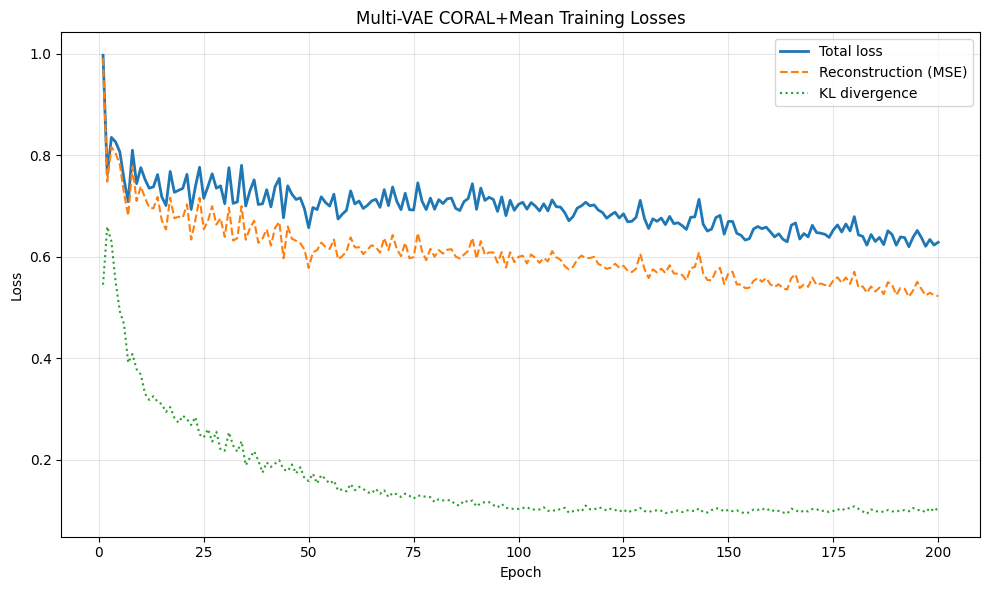

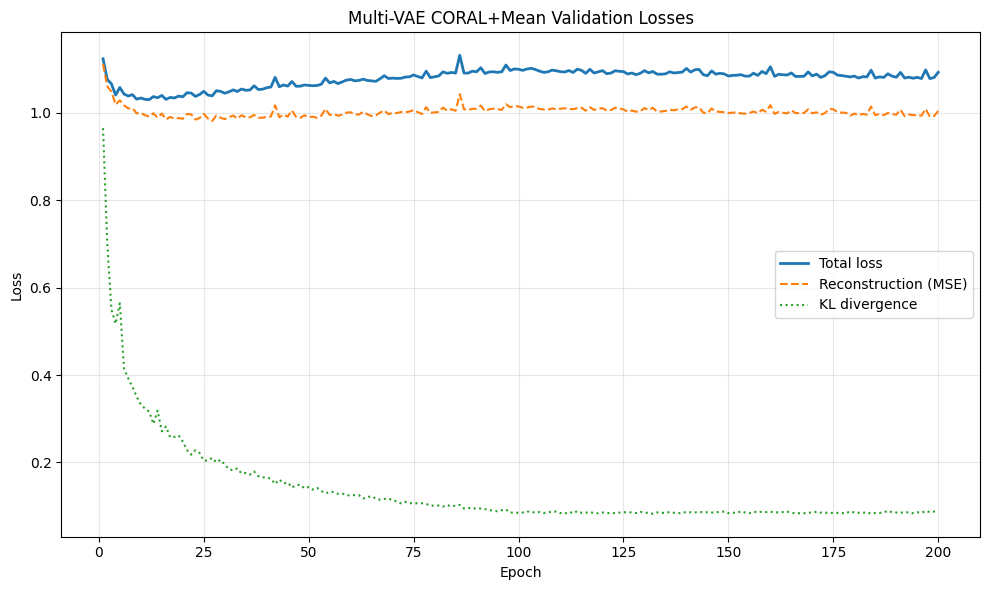

In [ ]:
plot_model_metrics(my_multivae_coral_mean, "Multi-VAE CORAL+Mean")

## t-SNE

In [ ]:
X_all = scaler.transform(data_final)
X_all_tensor = torch.tensor(X_all, dtype=torch.float32)
domain_train_tensor = torch.tensor(domain_ids, dtype=torch.long)

In [ ]:
all_dataset = TensorDataset(X_all_tensor, domain_train_tensor)
all_loader  = DataLoader(all_dataset, batch_size=256, shuffle=False)

Get latent means for all samples

In [ ]:
mus_all = eval_model(my_multivae_coral_mean, all_loader, device, use_domain=False)

Global t-SNE

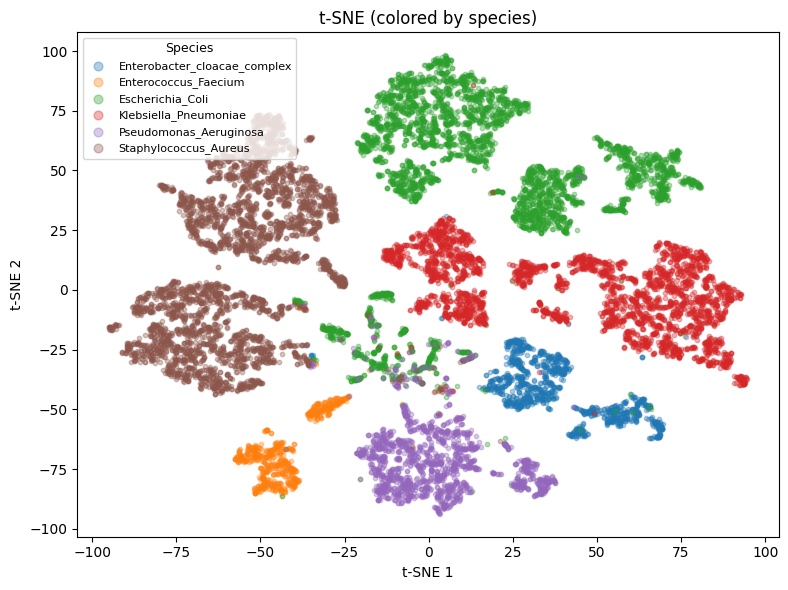

In [ ]:
tsne_df = compute_tsne_df(mus_all, label_final, meta_final)
plot_tsne_global(tsne_df, False)

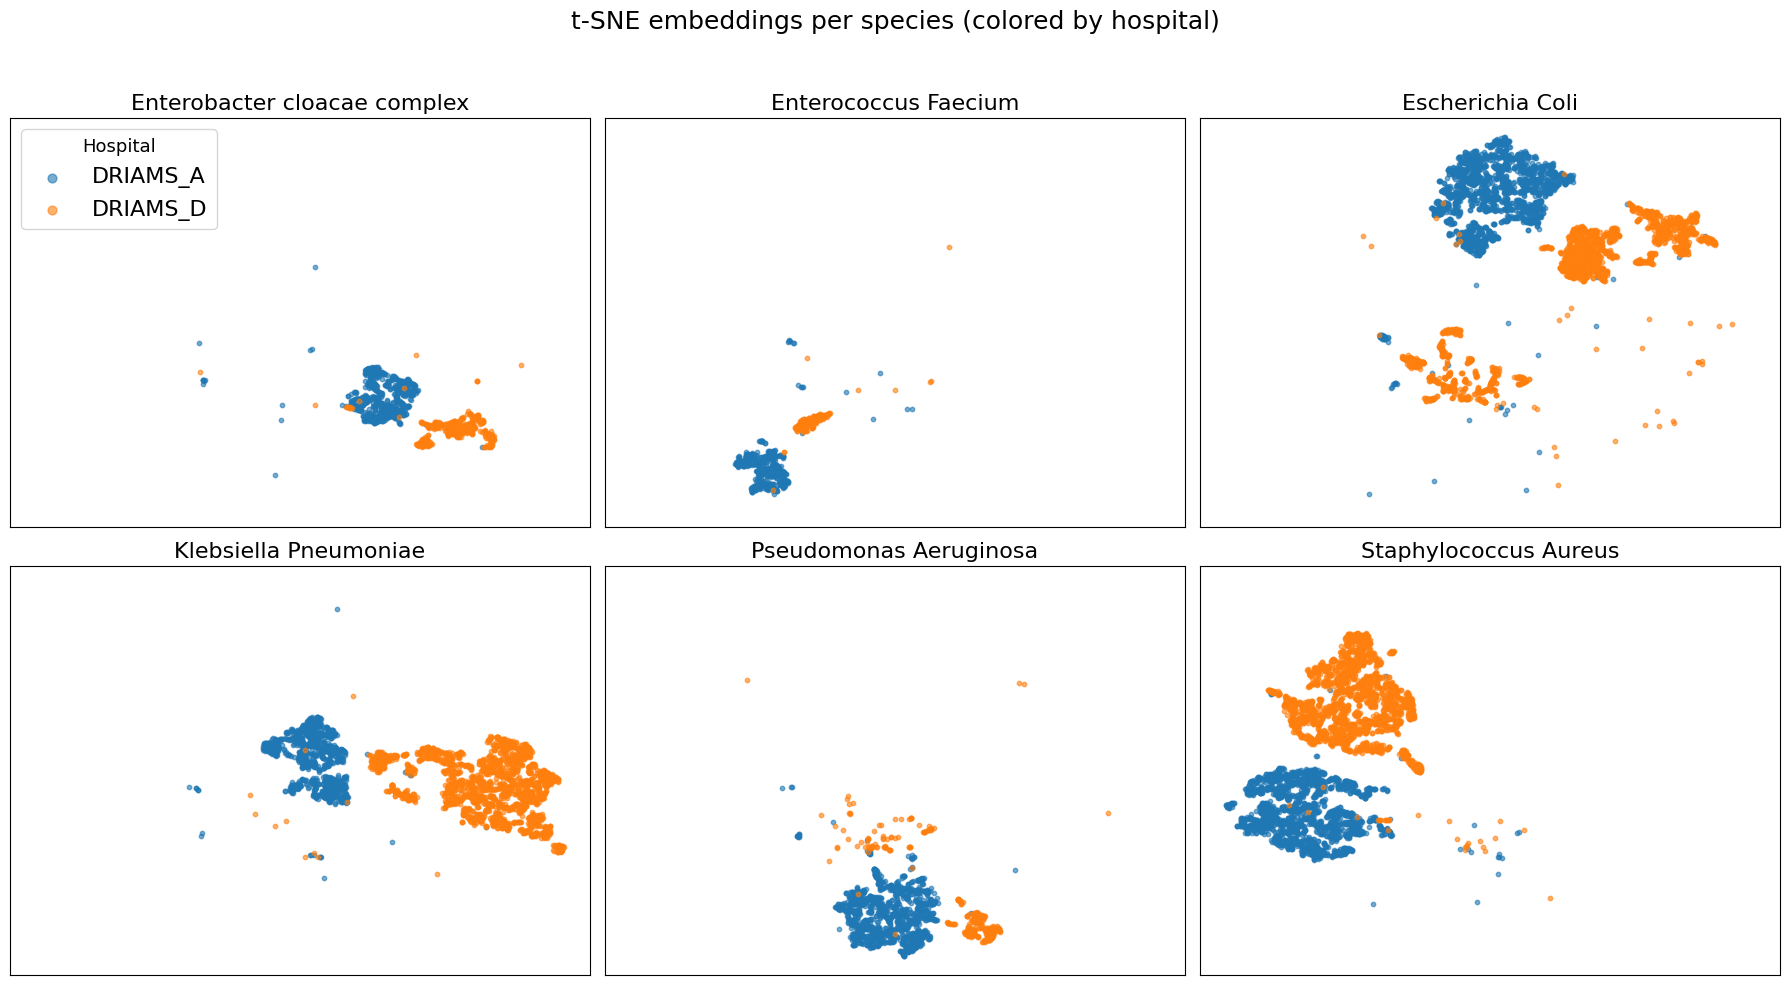

In [ ]:
plot_tsne_global(tsne_df, True)

t-SNE for each species separately

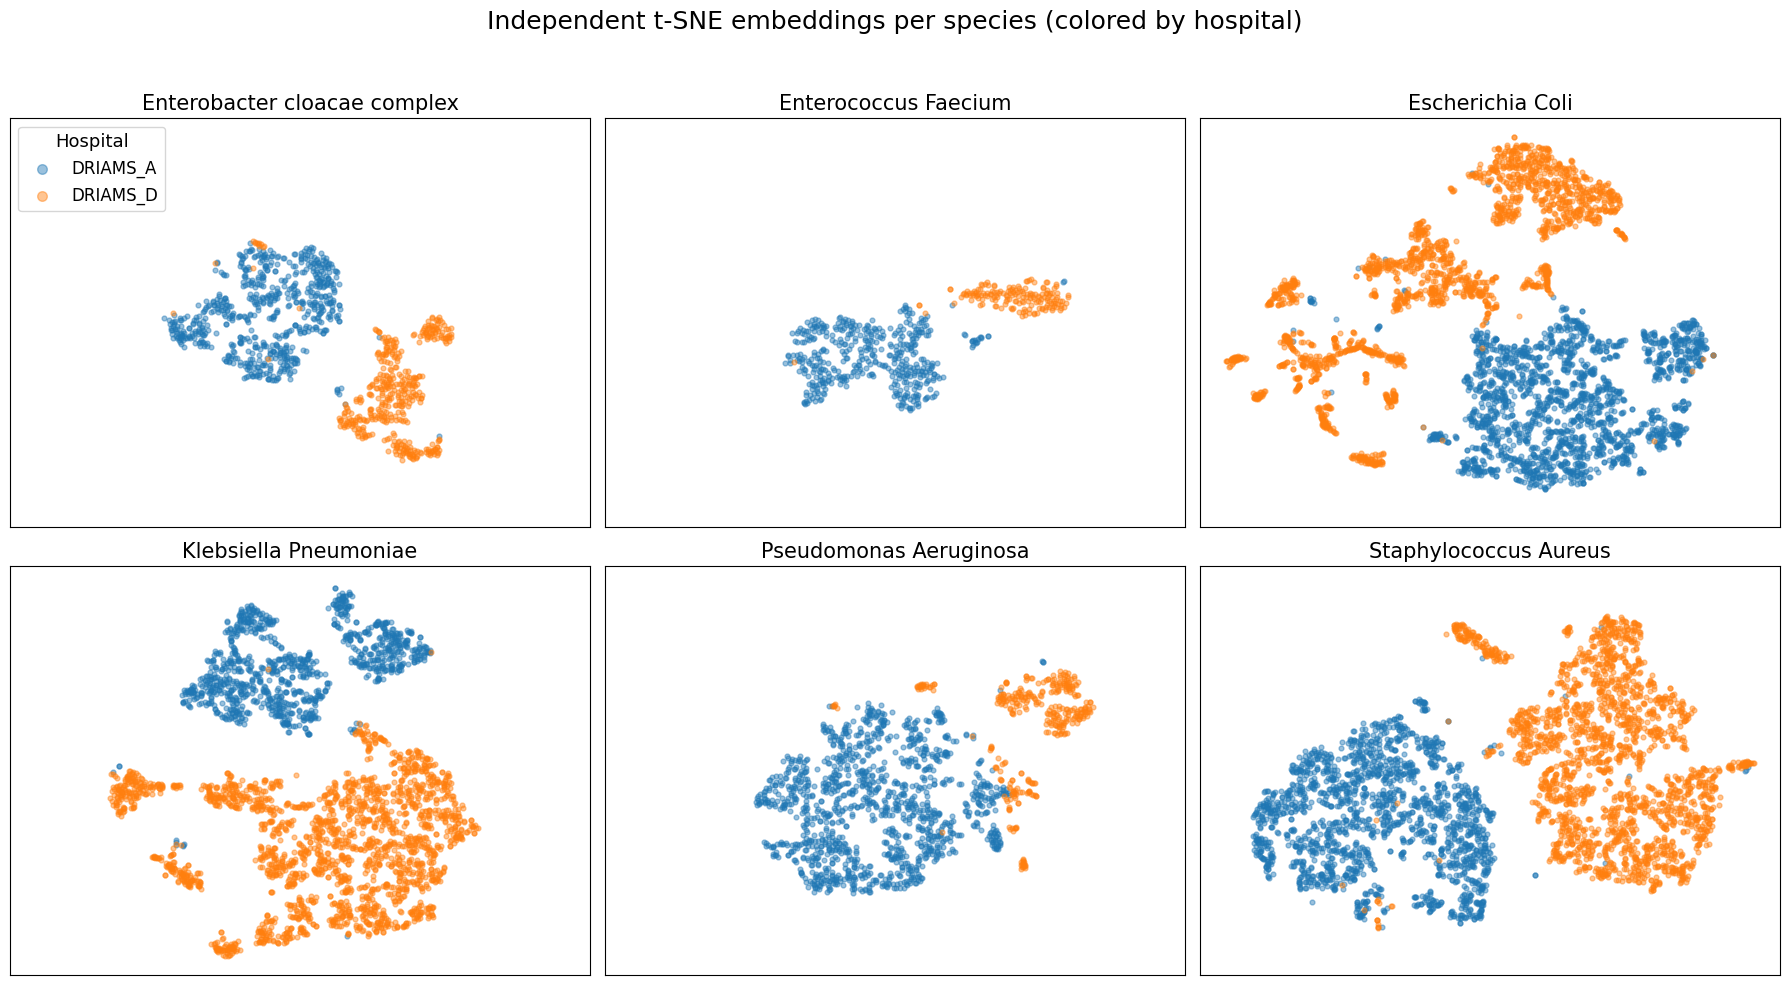

In [ ]:
df_all, tsne_results = compute_tsne_per_species(mus_all, label_final, meta_final)
plot_tsne_species(df_all, tsne_results)